In [21]:
from keras import models
from keras.layers import Dense, Dropout
from keras.utils import to_categorical
from keras.datasets import mnist


In [22]:
import livelossplot
plot_losses = livelossplot.PlotLossesKeras()
%matplotlib inline

In [23]:
data  = mnist.load_data() 
(x_train, y_train), (x_test, y_test) = data
print("Training images shape: ", x_train.shape)
print("Training labels shape: ", y_train.shape)
print("Testing images shape: ", x_test.shape)
print("Testing labels shape: ", y_test.shape)

Training images shape:  (60000, 28, 28)
Training labels shape:  (60000,)
Testing images shape:  (10000, 28, 28)
Testing labels shape:  (10000,)


In [24]:
print(y_train)
print(y_test)


[5 0 4 ... 5 6 8]
[7 2 1 ... 4 5 6]


In [25]:
x_train = x_train.reshape((60000, 28*28))
x_train = x_train.astype('float32')/255
x_test = x_test.reshape((10000, 28*28))
x_test = x_test.astype('float32')/255

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Training images shape: ", x_train.shape)
print("Training labels shape: ", y_train.shape)
print("Testing images shape: ", x_test.shape)
print("Testing labels shape: ", y_test.shape)

Training images shape:  (60000, 784)
Training labels shape:  (60000, 10)
Testing images shape:  (10000, 784)
Testing labels shape:  (10000, 10)


In [37]:
print(x_test)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [26]:
print(y_train)
print("\n y_test: \n")
print(y_test)

[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]

 y_test: 

[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [27]:
model = models.Sequential()
model.add(Dense(512, activation='relu', input_shape=(28*28,)))
model.add(Dropout(0.50))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.25)) 
model.add(Dense(10, activation = 'softmax'))

In [ ]:


model.fit(x_train, y_train, epochs=5, batch_size=128)

score  = model.evaluate(x_test, y_test, verbose=0)
print("Test loss: ", score[0])
print("Test accuracy: ", score[1])

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8990 - loss: 0.3322
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9523 - loss: 0.1561
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9631 - loss: 0.1250
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9677 - loss: 0.1058
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9729 - loss: 0.0938
Test loss:  0.06672348827123642
Test accuracy:  0.9800999760627747


In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,071,638 (4.09 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 535,820 (2.04 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted digit: 2
Actual digit: 2 

predicted value 



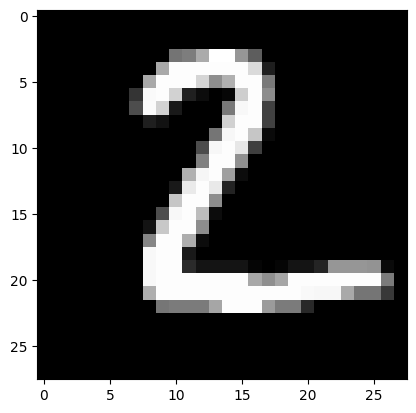

In [63]:
import numpy as np
import matplotlib.pyplot as plt
prediction = model.predict(x_test)
prediction_digit = np.argmax(prediction[1])
print("Predicted digit:", prediction_digit)
print("Actual digit:", np.argmax(y_test[1]),"\n")
print("predicted value \n")

plt.imshow(x_test[1].reshape(28, 28), cmap='gray')
plt.show()

In [46]:
import numpy as np

predicted_digit = np.argmax(prediction[0])

print("Predicted:", predicted_digit)
print("Actual:", np.argmax(y_test[0]))

Predicted: 7
Actual: 7


In [32]:
model.save('mnist_ann_model.keras')

In [ ]:
from PIL import Image
import numpy as np
img = Image.open('image1.jpg').convert('L')
img = img.resize((28, 28))
img_array = np.array(img)


img_array = img_array / 255.0
print(img_array.shape)
img_array = img_array.reshape(1, 784)
print(img_array.shape)
img_array = img_array.astype("float32")



(28, 28)
(1, 784)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted digit: 5


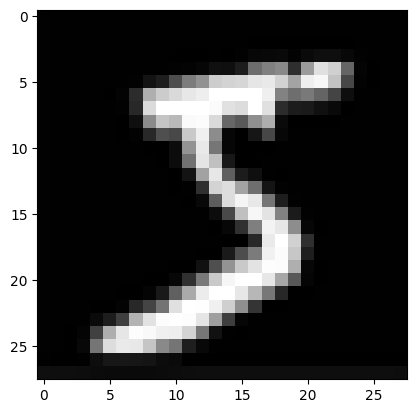

In [69]:
predict = model.predict(img_array)
prediction = np.argmax(predict[0])
print("Predicted digit:", prediction)
plt.imshow(img, cmap='gray')
plt.show()
